#Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
rows, columns = df.shape
print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 545
Number of Columns: 13


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
target = "price"

features = [col for col in df.columns if col != target]

print("Target Column:", target)
print("Feature Columns:")
print(features)

Target Column: price
Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [8]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#Task 2 — Data Cleaning

In [10]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [17]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

#Task 3 — Model Building

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [21]:
X = df.drop('price', axis=1)
y = df['price']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [23]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [24]:
lr_predictions = lr_model.predict(X_test)

In [25]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [26]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
rf_predictions = rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [30]:
print("Model Comparison")

print("Linear Regression R²= ", lr_r2)
print("Random Forest R²=   ", rf_r2)

if rf_r2 > lr_r2:
    print("Random Forest performed better.")
else:
    print("Linear Regression performed better.")

Model Comparison
Linear Regression R²=  0.6529242642153184
Random Forest R²=    0.611918531405699
Linear Regression performed better.


#Task 4 — Visualization

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import os
print(os.getcwd())

/content


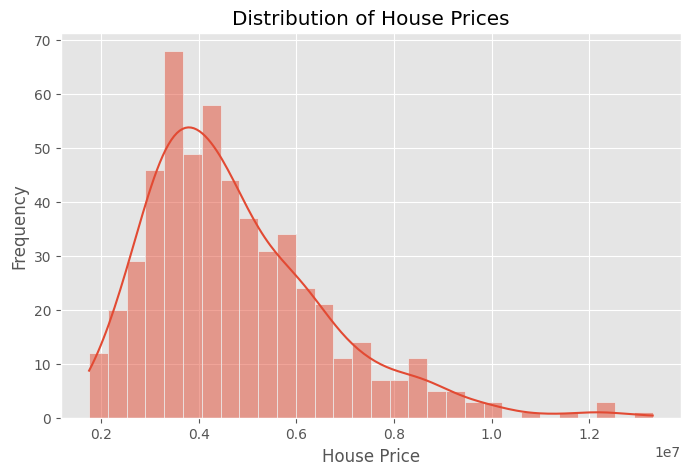

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig("charts/chart1_histogram.png")

plt.show()

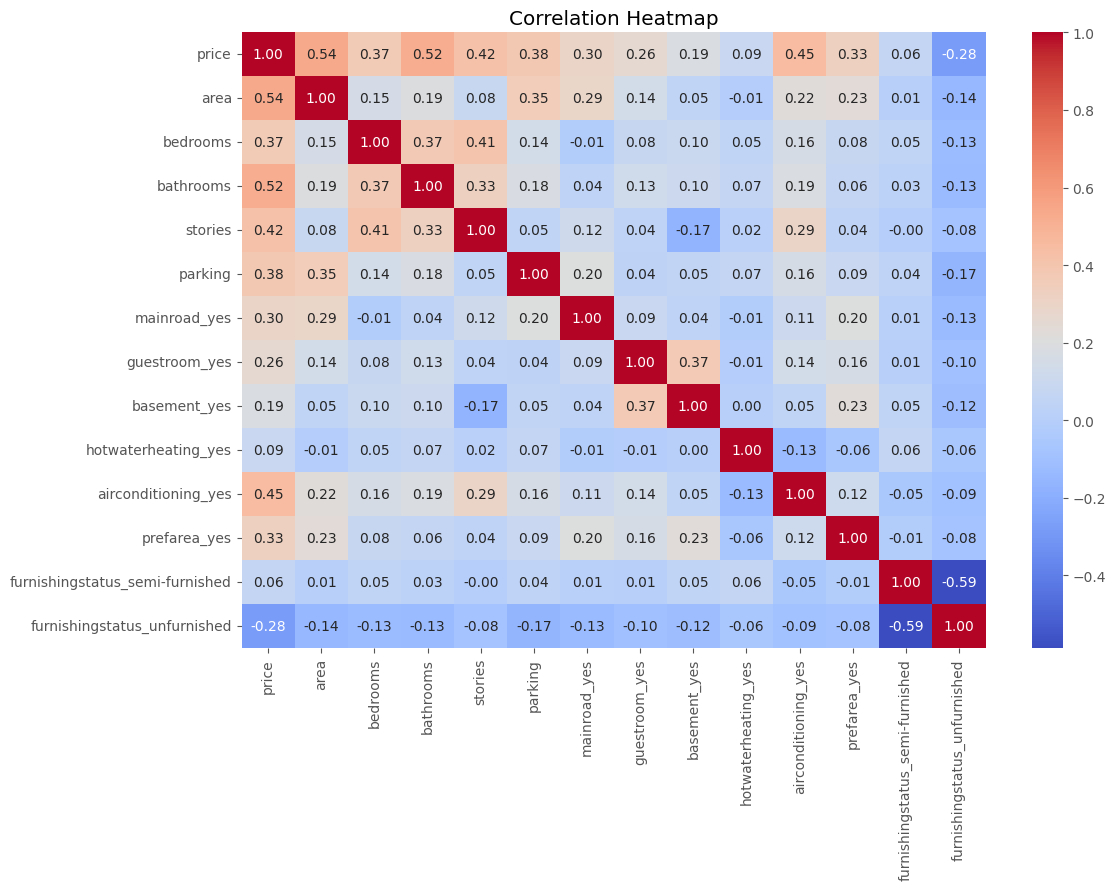

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("charts/chart2_heatmap.png")
plt.show()

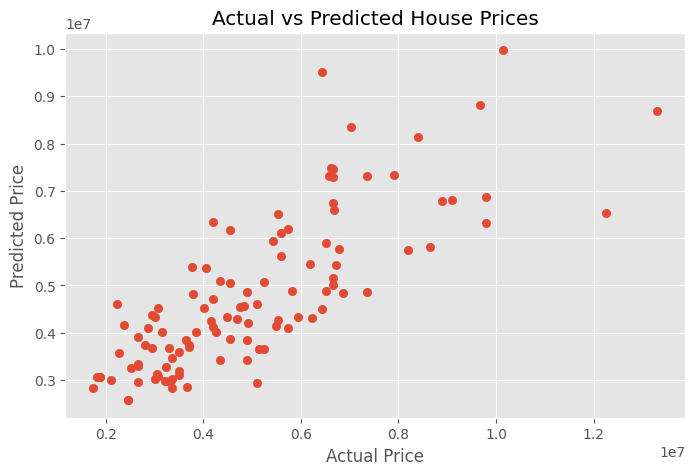

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/chart3_actual_vs_predicted.png")

plt.show()

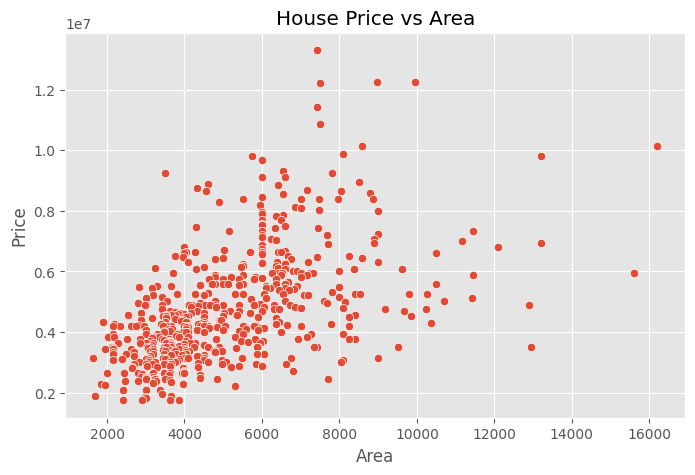

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='area',y='price',data=df)
plt.title("House Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig("charts/chart3_price_vs_area.png")
plt.show()